## Classical Flow Matching
Implementing a classical flow matching model to compare to the quantum model, which ended up being diffusion/flow matching inspired.

Heavily inspired by: [Flow Matching on MNIST](https://github.com/seichang00/flow-matching-lightning).

In [1]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

import os
import math
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils


/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
out_dir = "fm_outputs"
os.makedirs(out_dir, exist_ok=True)

batch_size = 32
epochs = 10
lr = 1e-3
image_size = 28
channels = 1
latent_std = 1.0  # standard deviation for gaussian prior
save_every = 10
subset_size = 10000  # Set to None to use full dataset

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),               # 0-1
    transforms.Normalize((0.5,), (0.5,)) # map to [-1, 1]
])
train_ds = datasets.MNIST(root="./mnist", train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=4)

if subset_size is not None:
    train_ds = torch.utils.data.Subset(train_ds, range(subset_size))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 278kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.43MB/s]


In [5]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.lin = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.SiLU(),
            nn.Linear(dim*4, dim)
        )

    def forward(self, t):
        # sinusoidal embedding (like transformer / diffusion)
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device) / half)
        args = t.unsqueeze(-1) * freqs.unsqueeze(0)  # (B, half)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.lin(emb)
    
class SmallConvField(nn.Module):
    def __init__(self, in_ch=1, base_ch=64, time_emb_dim=32):
        super().__init__()
        self.time_emb = TimeEmbedding(time_emb_dim)

        self.init_conv = nn.Conv2d(in_ch + 1, base_ch, kernel_size=3, padding=1) # +1 channel for time broadcast
        self.down1 = nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1)
        self.down2 = nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1)

        self.mid = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.SiLU()
        )

        # inject time embedding to final layers via broadcasting and addition
        self.final = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, kernel_size=3, padding=1)  # predict same-channel vector field
        )

        self.time_proj = nn.Linear(time_emb_dim, base_ch)

    def forward(self, x, t):
        """
        x: (B, C, H, W) where C=1 (image)
        t: (B,) in [0,1]
        returns v(x,t) shape same as x
        """
        B, C, H, W = x.shape
        # broadcast time as an extra channel (scalar per image)
        t_channel = t.view(B, 1, 1, 1).expand(-1, 1, H, W)
        xt = torch.cat([x, t_channel], dim=1)  # (B, C+1, H, W)
        h = self.init_conv(xt)
        h = F.silu(self.down1(h) + h)
        h = F.silu(self.down2(h) + h)

        h = self.mid(h)
        # time embedding projection and add
        t_emb = self.time_emb(t)             # (B, time_emb_dim)
        t_proj = self.time_proj(t_emb)       # (B, base_ch)
        t_proj = t_proj.view(B, -1, 1, 1)    # (B, base_ch, 1, 1)
        h = h + t_proj

        out = self.final(h)
        return out

In [6]:
def linear_mix(x0, x1, t):
    # x_t = (1 - t) * x0 + t * x1
    return (1.0 - t.view(-1,1,1,1)) * x0 + t.view(-1,1,1,1) * x1

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch}")
    for imgs, _ in pbar:
        imgs = imgs.to(device)  # x0: (B,1,28,28) in [-1,1]
        B = imgs.shape[0]

        # sample random prior images x1 ~ N(0, I)
        x1 = torch.randn_like(imgs) * latent_std

        # sample t uniformly in [0,1)
        t = torch.rand(B, device=device)

        # construct x_t
        x_t = linear_mix(imgs, x1, t)

        # target vector field: dx_t/dt = x1 - x0 (constant for linear interpolation)
        target_v = (x1 - imgs)

        # predict v(x_t, t)
        pred_v = model(x_t, t)

        loss = F.mse_loss(pred_v, target_v)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * B
        pbar.set_postfix(loss=loss.item())

    return total_loss / len(loader.dataset)

@torch.no_grad()
def rk4_integration(model, x_init, t0=1.0, t1=0.0, steps=50):
    """
    Integrate dx/dt = v(x, t) from t0 -> t1 using RK4
    x_init: (B, C, H, W) initial states at time t0
    returns x_final at t1
    """
    model.eval()
    x = x_init.clone()
    B = x.shape[0]
    t0 = float(t0)
    t1 = float(t1)
    dt = (t1 - t0) / steps  # negative if t1 < t0

    t = t0
    for i in range(steps):
        t_tensor = torch.full((B,), t, device=x.device)
        k1 = model(x, t_tensor)
        k2 = model(x + 0.5 * dt * k1, t_tensor + 0.5 * dt)
        k3 = model(x + 0.5 * dt * k2, t_tensor + 0.5 * dt)
        k4 = model(x + dt * k3, t_tensor + dt)
        x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t = t + dt
    return x

def sample_and_save(model, epoch, n=64, steps=80):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, channels, image_size, image_size, device=device) * latent_std  # sample from prior at t=1
        x = rk4_integration(model, z, t0=1.0, t1=0.0, steps=steps)
        # map back from [-1,1] to [0,1] for visualization
        imgs = (x.clamp(-1,1) + 1.0) / 2.0
        grid = utils.make_grid(imgs, nrow=int(math.sqrt(n)), pad_value=1.0)
        save_path = os.path.join(out_dir, f"samples_epoch_{epoch}.png")
        utils.save_image(grid, save_path)
        print(f"Saved samples to {save_path}")
        return imgs

Epoch 1: 100%|██████████| 312/312 [00:46<00:00,  6.67it/s, loss=0.251]


Epoch 1 average loss: 0.430018


Epoch 2: 100%|██████████| 312/312 [00:45<00:00,  6.80it/s, loss=0.223]


Epoch 2 average loss: 0.262753


Epoch 3: 100%|██████████| 312/312 [00:46<00:00,  6.71it/s, loss=0.239]


...

Epoch 8 average loss: 0.227231


Epoch 9: 100%|██████████| 312/312 [00:46<00:00,  6.68it/s, loss=0.202]


Epoch 9 average loss: 0.223744


Epoch 10: 100%|██████████| 312/312 [00:46<00:00,  6.74it/s, loss=0.202]


Epoch 10 average loss: 0.219016
Saved samples to fm_outputs/samples_epoch_10.png
Saved model checkpoint.


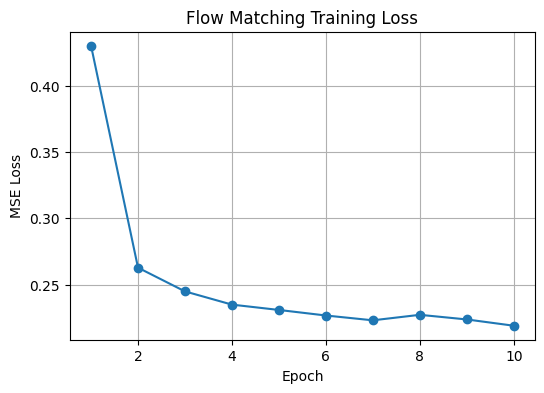

In [7]:
model = SmallConvField(in_ch=channels, base_ch=64, time_emb_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

loss_history = []

for epoch in range(1, epochs+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, epoch)
    loss_history.append(train_loss)
    print(f"Epoch {epoch} average loss: {train_loss:.6f}")

    if epoch % save_every == 0 or epoch == epochs:
        sample_and_save(model, epoch, n=64, steps=100)
        torch.save(model.state_dict(), os.path.join(out_dir, f"model_epoch_{epoch}.pth"))
        print("Saved model checkpoint.")

plt.figure(figsize=(6,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.title("Flow Matching Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

Eval samples: 200
Pixel-space FID (lower is better): 23.5183
Mean L1 (paired): 0.175426
Mean L2 (paired): 0.140765
Wasserstein (paired): 0.044301


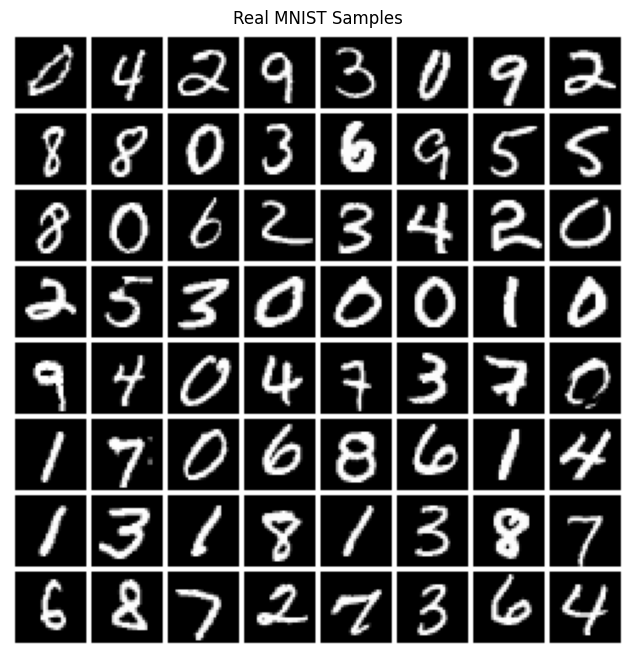

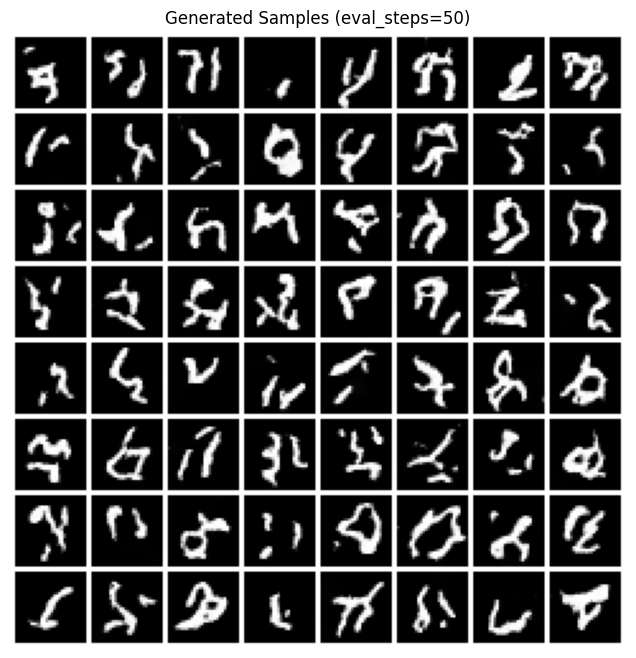

In [9]:
# Note: FID here is pixel-space (not Inception), useful for relative tracking only.

from scipy.linalg import sqrtm
from scipy.stats import wasserstein_distance

# eval config
eval_samples = 200  # increase for more stable metrics
eval_batch = 128
eval_steps = 50

# test set
test_ds = datasets.MNIST(root="./mnist", train=False, download=True, transform=transform)
test_loader = DataLoader(test_ds, batch_size=eval_batch, shuffle=True, drop_last=False, num_workers=2)

def generate_samples(model, n, steps=80):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, channels, image_size, image_size, device=device) * latent_std
        x = rk4_integration(model, z, t0=1.0, t1=0.0, steps=steps)
        imgs = (x.clamp(-1, 1) + 1.0) / 2.0
    return imgs

# gather real samples
real_batches = []
for imgs, _ in test_loader:
    real_batches.append(imgs)
    if sum(b.shape[0] for b in real_batches) >= eval_samples:
        break
real_imgs = torch.cat(real_batches, dim=0)[:eval_samples]
real_imgs = (real_imgs.clamp(-1, 1) + 1.0) / 2.0

# generate samples
gen_imgs = generate_samples(model, eval_samples, steps=eval_steps)

# move to cpu numpy
real_np = real_imgs.detach().cpu().numpy()
gen_np = gen_imgs.detach().cpu().numpy()

def calculate_statistics(data):
    data = data.reshape(data.shape[0], -1)
    mean = np.mean(data, axis=0)
    covariance = np.cov(data, rowvar=False)
    return mean, covariance

def calculate_fid_stable(mu1, sigma1, mu2, sigma2, eps=1e-6):
    diff = mu1 - mu2
    sigma1_eps = sigma1 + np.eye(sigma1.shape[0]) * eps
    sigma2_eps = sigma2 + np.eye(sigma2.shape[0]) * eps
    covmean = sqrtm(sigma1_eps @ sigma2_eps)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)
    return float(fid)

def calculate_wasserstein(real_data, generated_data):
    num_samples = real_data.shape[0]
    wasserstein_scores = []
    for i in range(num_samples):
        w_score = wasserstein_distance(real_data[i].ravel(), generated_data[i].ravel())
        wasserstein_scores.append(w_score)
    return float(np.mean(wasserstein_scores))

mu_r, sigma_r = calculate_statistics(real_np)
mu_g, sigma_g = calculate_statistics(gen_np)
fid_pixel = calculate_fid_stable(mu_r, sigma_r, mu_g, sigma_g)

# simple paired stats (index-paired, not a true perceptual metric)
l1 = float(np.mean(np.abs(real_np - gen_np)))
l2 = float(np.mean((real_np - gen_np) ** 2))
w_dist = calculate_wasserstein(real_np, gen_np)

print(f"Eval samples: {eval_samples}")
print(f"Pixel-space FID (lower is better): {fid_pixel:.4f}")
print(f"Mean L1 (paired): {l1:.6f}")
print(f"Mean L2 (paired): {l2:.6f}")
print(f"Wasserstein (paired): {w_dist:.6f}")

# visuals
def show_grid(imgs, nrow=8, title=None):
    grid = utils.make_grid(imgs, nrow=nrow, pad_value=1.0)
    plt.figure(figsize=(nrow, nrow))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

show_grid(real_imgs[:64], nrow=8, title="Real MNIST Samples")
show_grid(gen_imgs[:64], nrow=8, title=f"Generated Samples (eval_steps={eval_steps})")